# PedSilicoICH: Part 1. Phantoms and Lesion Generation

This notebook demonstrates how to load anthropomorphic phantoms and procedurally generate realistic intracranial hemorrhage (ICH) lesions using the `insilicoICH` library. We will cover:

1.  **Loading Phantoms**: Accessing available head phantoms (e.g., NIHPD, UNC, MIDA).
2.  **Lesion Generation**: Creating different types of lesions (IPH, EDH, SDH).
3.  **Lesion Insertion**: Placing lesions into the phantom.
4.  **Parameter Exploration**: Controlling volume, texture, contrast, and mass effect.

## 1. Setup and Phantom Loading

First, we import the necessary modules and load a base phantom. We'll use the `VITools` library to access available phantoms.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import VITools
from insilicoICH.lesion_definition import LesionFactory

# List available phantoms
available_phantoms = VITools.get_available_phantoms()
print("Available Phantoms:", list(available_phantoms.keys()))

# Load a specific phantom (e.g., 6.5 year old NIHPD Head)
phantom_name = '6.5 yr NIHPD Head'
# Ensure you have PHANTOM_DIRECTORY set in your environment or .env file
if phantom_name in available_phantoms:
    phantom = available_phantoms[phantom_name]()
    print(f"\nLoaded: {phantom}")
else:
    print(f"Phantom '{phantom_name}' not found. Please check your configuration.")

/home/sarah/Dev/InSilicoICH/src/insilicoICH/phantoms/head_phantoms.py:36: UserWarning: 
The environment variable `PHANTOM_DIRECTORY` has not been set, this is needed
to locate stored base phantom files for the NIHPD and MIDA head phantoms.

If these phantom files cannot be located, NIHPD phantoms will be downloaded to
your working directory: /home/sarah/Dev/InSilicoICH/src

MIDA phantom files need to be downloaded manually and added to this directory,
see `MIDA_Head_Phantom` for details.

Please do one of the following:

1. create a file called `.env` in this project's working directory and add:

`PHANTOM_DIRECTORY=/path/to/phantoms`

or

2. in your terminal `export PHANTOM_DIRECTORY=/path/to_phantoms`

  warn(f'''


Available Phantoms: ['Water Phantom', '0.0 yr UNC Head', '1.0 yr UNC Head', '2.0 yr UNC Head', '6.5 yr NIHPD Head', '9.0 yr NIHPD Head', '10.5 yr NIHPD Head', '11.5 yr NIHPD Head', '12.0 yr NIHPD Head', '15.75 yr NIHPD Head', '38.0 yr MIDA Head']
pseudo-CT images not found; defaulting to otsu segmentation method

Loaded: 
        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (151.2, 186.4, 157.6)
        
Number of lesions: 0



## 2. Intraparenchymal Hemorrhage (IPH)

IPH lesions are generated within the brain parenchyma. We use `LesionFactory` to create an 'IPH' lesion object. We need to provide a boundary mask (e.g., white matter) to constrain the lesion location.

In [2]:
# Create an IPH lesion restricted to white matter
# Note: get_material_mask returns a binary mask of the specified tissue
boundary_mask = phantom.get_material_mask('white matter')

lesion_iph = LesionFactory.create('IPH',
                                  spacings=phantom.spacings,
                                  boundary=boundary_mask,
                                  seed=42) # Fixed seed for reproducibility

# Generate the lesion with specific parameters
lesion_iph.generate(
    volume_ml=15.0,          # Target volume in mL
    intensity_hu=60,         # Mean intensity in Hounsfield Units
    texture_scale=10.0,      # Scale of the internal texture patterns
    texture_contrast=0.1,    # Contrast of the texture (fraction of intensity)
    complexity=3,            # Shape complexity (number of overlapping blobs)
    smoothness=0.5,          # Smoothness of the surface
    irregularity=0.5,        # Surface irregularity magnitude
    eccentricity=0.6,        # Elongation of the base shape
    edema_thickness=3        # Perihematomal edema thickness in voxels
)

print(f"Generated IPH Lesion: {lesion_iph}")

Generated IPH Lesion: Lesion(type=IPH, volume_ml=15.02, coords_voxel=(79, 104, 126), seed=42)


### visualizing the IPH Lesion

Let's visualize the generated lesion mask before inserting it into the phantom.

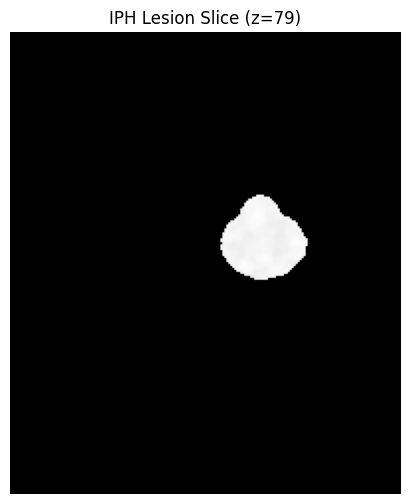

In [3]:
def show_lesion(lesion_obj):
    if lesion_obj.mask is None:
        print("Lesion not generated yet.")
        return

    # Find the center slice of the lesion
    center_z = lesion_obj.coords_voxel[0]

    plt.figure(figsize=(6, 6))
    plt.imshow(lesion_obj.image[center_z], cmap='gray')
    plt.title(f"{lesion_obj.lesion_type} Lesion Slice (z={center_z})")
    plt.axis('off')
    plt.show()

show_lesion(lesion_iph)

## 3. Inserting the Lesion into the Phantom

Now we insert the generated lesion into the phantom. We can also apply **mass effect**, which simulates the displacement of surrounding tissue.

In [4]:
# Insert the lesion with mass effect
# mass_effect=True uses a default strength,
# or pass a float (e.g., 0.5) to control the strength directly.
phantom.insert_lesion(lesion_iph, mass_effect=0.5)

print(phantom)


        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (151.2, 186.4, 157.6)
        
Number of lesions: 1
  - Lesion 1: IPH, Volume: 15.02 mL, Center: (79, 104, 126)
Mass effect strength: 0.5


### Visualization of Phantom with Lesion

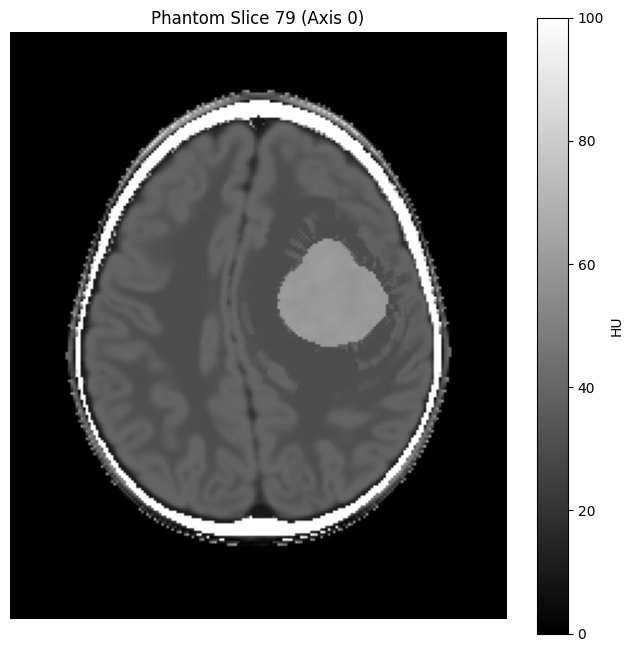

In [5]:
def show_phantom_slice(phant_obj, slice_idx=None, axis=0):
    """Helper to view phantom slice. Axis 0=Axial, 1=Coronal, 2=Sagittal"""
    vol = phant_obj.get_CT_number_phantom()
    if slice_idx is None:
        slice_idx = vol.shape[axis] // 2

    if axis == 0:
        img = vol[slice_idx, :, :]
    elif axis == 1:
        img = vol[:, slice_idx, :]
    else:
        img = vol[:, :, slice_idx]

    plt.figure(figsize=(8, 8))
    # Rotate for better viewing if needed (depends on phantom orientation)
    # Standard orientation often needs rotation for medical view convention
    # But raw array view is fine for demo.
    plt.imshow(img, cmap='gray', vmin=0, vmax=100) # Window for soft tissue
    plt.title(f"Phantom Slice {slice_idx} (Axis {axis})")
    plt.axis('off')
    plt.colorbar(label='HU')
    plt.show()

# Show the slice containing the lesion center
lesion_z = lesion_iph.coords_voxel[0]
show_phantom_slice(phantom, slice_idx=lesion_z, axis=0)

## 4. Epidural (EDH) and Subdural (SDH) Hematomas

Extra-axial lesions like EDH and SDH require a valid **dura map** or skull boundary to conform to the inner table of the skull.

Phantom now has 8 lesions.


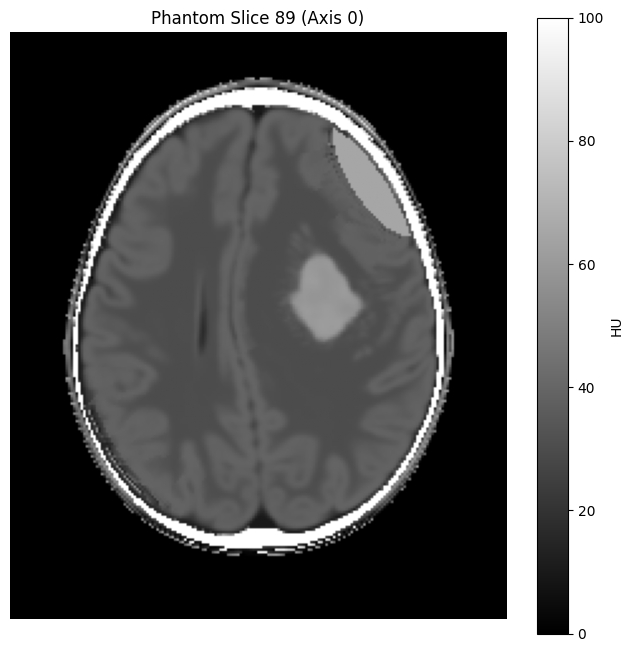

In [9]:
# Get the dura boundary map from the phantom
dura_map = phantom.get_dura_map()

# Create an Epidural Hematoma (EDH)
# EDH shapes are typically lenticular (lens-shaped)
lesion_edh = LesionFactory.create('EDH',
                                  spacings=phantom.spacings,
                                  boundary=dura_map,
                                  seed=101)

lesion_edh.generate(volume_ml=5.0, intensity_hu=65)
phantom.insert_lesion(lesion_edh, mass_effect=0.3)

# Create a Subdural Hematoma (SDH)
# SDH shapes are typically crescentic
lesion_sdh = LesionFactory.create('SDH',
                                  spacings=phantom.spacings,
                                  boundary=dura_map,
                                  seed=202)

lesion_sdh.generate(volume_ml=8.0, intensity_hu=55)
phantom.insert_lesion(lesion_sdh, mass_effect=0.3)

# Visualize the new lesions
print(f"Phantom now has {len(phantom.lesions)} lesions.")

# Find slice for EDH
edh_z = lesion_edh.coords_voxel[0]
show_phantom_slice(phantom, slice_idx=edh_z, axis=0)

## 5. Noise Textures and Heterogeneity

You can simulate realistic tissue heterogeneity (e.g., the "swirl sign" in acute ICH) by adjusting `texture_scale`, `texture_contrast`, and using `mixture` parameters if available.

Here we compare two IPH lesions with different texture settings.

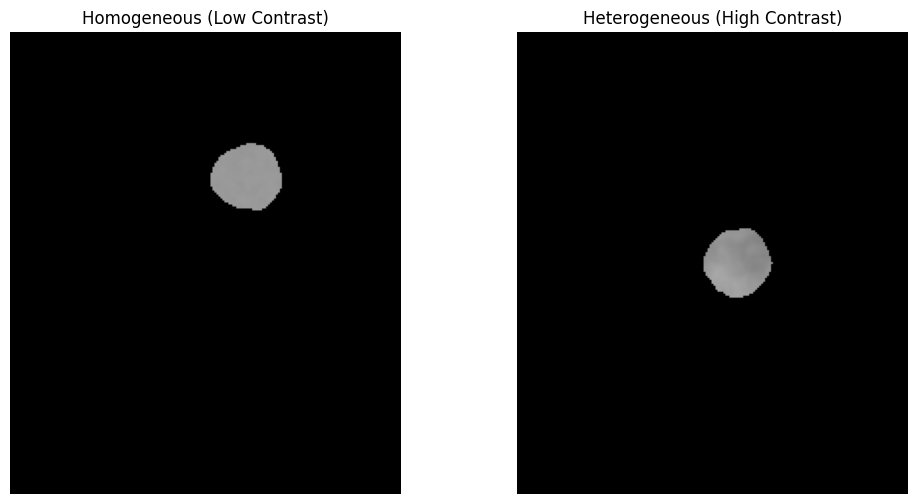

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Lesion 1: Homogeneous (Low Texture Contrast)
l1 = LesionFactory.create('IPH', spacings=phantom.spacings, boundary=boundary_mask, seed=1)
l1.generate(volume_ml=10, intensity_hu=60, texture_contrast=0.05, texture_scale=5)

# Lesion 2: Heterogeneous (High Texture Contrast, Larger Scale)
l2 = LesionFactory.create('IPH', spacings=phantom.spacings, boundary=boundary_mask, seed=2)
l2.generate(volume_ml=10, intensity_hu=60, texture_contrast=0.3, texture_scale=20)

z1 = l1.coords_voxel[0]
z2 = l2.coords_voxel[0]

axes[0].imshow(l1.image[z1], cmap='gray', vmin=0, vmax=100)
axes[0].set_title("Homogeneous (Low Contrast)")
axes[0].axis('off')

axes[1].imshow(l2.image[z2], cmap='gray', vmin=0, vmax=100)
axes[1].set_title("Heterogeneous (High Contrast)")
axes[1].axis('off')

plt.show()